<a href="https://colab.research.google.com/github/YuriFla94/Processamento-de-Sinais-1/blob/main/Tarefa5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTÃO 1

### 1. Carregamento e Preparação do Áudio (`handel.wav`)

Vamos importar as bibliotecas essenciais e carregar o sinal de áudio já disponível no ambiente de execução.

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import fft, ifft, dct, idct
from IPython.display import Audio, display

audio_path = '/content/handel.wav'

# Carregar o áudio original
fs, data = wavfile.read(audio_path)

# Normalizar o sinal para float entre -1.0 e 1.0
if data.dtype == np.int16:
    x = data / 32768.0
elif data.dtype == np.uint8:
    x = (data - 128) / 128.0
else:
    x = data.astype(float)

print(f"Taxa de amostragem: {fs} Hz")
print(f"Número total de amostras: {len(x)}")
print(f"Duração do sinal: {len(x)/fs:.2f} segundos")

display(Audio(x, rate=fs))

Taxa de amostragem: 8192 Hz
Número total de amostras: 73113
Duração do sinal: 8.92 segundos


### 2. Função de Compressão por Limiar de Energia

Esta função aplica a transformada especificada (DFT ou DCT), seleciona ordenadamente os maiores coeficientes até que a soma acumulada de suas energias atinja a fração $r$ (limiar) da energia total do sinal original, e reconstrói o sinal de áudio correspondente zerando os demais.

In [7]:
def compress_signal(x, r, transform_type='dft'):
    N = len(x)
    if transform_type == 'dft':
        X = fft(x)
        # A energia de cada coeficiente da DFT é obtida pelo quadrado do valor absoluto
        energy = np.abs(X)**2
    elif transform_type == 'dct':
        X = dct(x, norm='ortho')
        energy = X**2

    total_energy = np.sum(energy)
    target_energy = r * total_energy

    # Ordenar os coeficientes de forma decrescente pela sua contribuição de energia
    sorted_indices = np.argsort(energy)[::-1]

    # Acumular energia ordenada para identificar o ponto de corte
    cum_energy = np.cumsum(energy[sorted_indices])
    num_coefs = np.searchsorted(cum_energy, target_energy) + 1

    # Zerar os coeficientes menos energéticos
    keep_indices = sorted_indices[:num_coefs]
    X_compressed = np.zeros_like(X)
    X_compressed[keep_indices] = X[keep_indices]

    # Reconstrução com a transformada inversa correspondente
    if transform_type == 'dft':
        x_rec = np.real(ifft(X_compressed))
    elif transform_type == 'dct':
        x_rec = idct(X_compressed, norm='ortho')

    # Calcular o Erro Quadrático Médio (MSE)
    mse = np.mean((x - x_rec)**2)

    return x_rec, num_coefs, mse

### 3. Teste Empírico e Resultados Comparativos

Vamos aplicar os cinco limiares de energia $r$ estabelecidos tanto para DFT quanto para DCT e apresentar o resumo quantitativo.

In [8]:
r_values = [0.995, 0.990, 0.900, 0.750, 0.500]
results = {'dft': {'coefs': [], 'mse': [], 'signals': []},
           'dct': {'coefs': [], 'mse': [], 'signals': []}}

for r in r_values:
    for t_type in ['dft', 'dct']:
        x_rec, n_coefs, mse = compress_signal(x, r, transform_type=t_type)
        results[t_type]['coefs'].append(n_coefs)
        results[t_type]['mse'].append(mse)
        results[t_type]['signals'].append(x_rec)

# Exibição tabulada das métricas
print(f"{'Fator r':<10} | {'Transformada':<12} | {'Coefs Utilizados':<20} | {'% Coefs':<10} | {'MSE':<12}")
print("-"*70)
for i, r in enumerate(r_values):
    for t_type in ['dft', 'dct']:
        n_coefs = results[t_type]['coefs'][i]
        pct_coefs = (n_coefs / len(x)) * 100
        mse = results[t_type]['mse'][i]
        print(f"{r*100:9.1f}% | {t_type.upper():<12} | {n_coefs:<20} | {pct_coefs:8.2f}% | {mse:.2e}")
    print("-"*70)

Fator r    | Transformada | Coefs Utilizados     | % Coefs    | MSE         
----------------------------------------------------------------------
     99.5% | DFT          | 48670                |    66.57% | 1.93e-04
     99.5% | DCT          | 40702                |    55.67% | 1.93e-04
----------------------------------------------------------------------
     99.0% | DFT          | 40986                |    56.06% | 3.85e-04
     99.0% | DCT          | 33683                |    46.07% | 3.85e-04
----------------------------------------------------------------------
     90.0% | DFT          | 11661                |    15.95% | 3.85e-03
     90.0% | DCT          | 9038                 |    12.36% | 3.85e-03
----------------------------------------------------------------------
     75.0% | DFT          | 4325                 |     5.92% | 9.63e-03
     75.0% | DCT          | 3200                 |     4.38% | 9.63e-03
---------------------------------------------------------------

### 4. Análise Gráfica de Desempenho

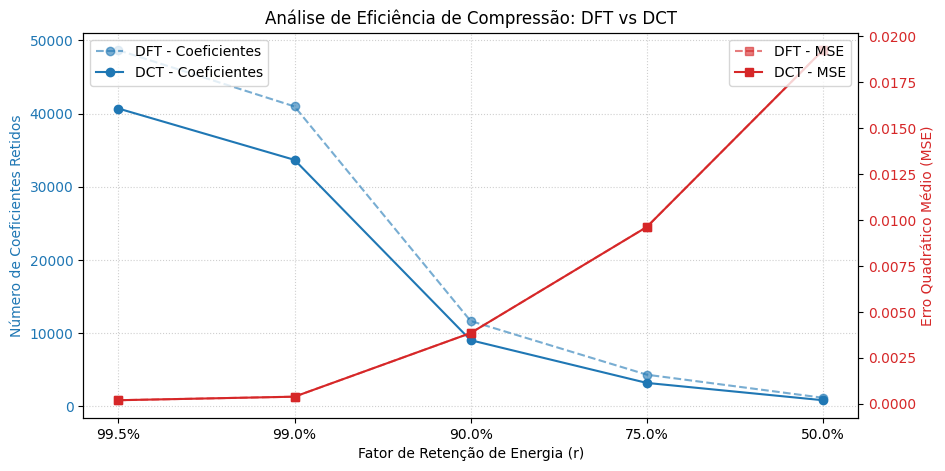

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))

r_labels = [f"{r*100}%" for r in r_values]
x_axis = np.arange(len(r_values))

# Plot do número de coeficientes retidos
color = 'tab:blue'
ax1.set_xlabel('Fator de Retenção de Energia (r)')
ax1.set_ylabel('Número de Coeficientes Retidos', color=color)
ax1.plot(x_axis, results['dft']['coefs'], 'o--', label='DFT - Coeficientes', color=color, alpha=0.6)
ax1.plot(x_axis, results['dct']['coefs'], 'o-', label='DCT - Coeficientes', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x_axis)
ax1.set_xticklabels(r_labels)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot do MSE associado
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Erro Quadrático Médio (MSE)', color=color)
ax2.plot(x_axis, results['dft']['mse'], 's--', label='DFT - MSE', color=color, alpha=0.6)
ax2.plot(x_axis, results['dct']['mse'], 's-', label='DCT - MSE', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Análise de Eficiência de Compressão: DFT vs DCT')
plt.show()

### 5. Reprodutores de Áudio para Avaliação Subjetiva

Use os tocadores abaixo para realizar o teste de escuta subjetivo, comparando o sinal original com as versões comprimidas sob diferentes taxas.

In [10]:
print("=== ÁUDIO ORIGINAL ===")
display(Audio(x, rate=fs))

for i, r in enumerate(r_values):
    print(f"\n=== RETENÇÃO DE ENERGIA r = {r*100}% ===")
    print("DFT:")
    display(Audio(results['dft']['signals'][i], rate=fs))
    print("DCT:")
    display(Audio(results['dct']['signals'][i], rate=fs))

=== ÁUDIO ORIGINAL ===



=== RETENÇÃO DE ENERGIA r = 99.5% ===
DFT:


DCT:



=== RETENÇÃO DE ENERGIA r = 99.0% ===
DFT:


DCT:


...

DCT:



=== RETENÇÃO DE ENERGIA r = 75.0% ===
DFT:


DCT:



=== RETENÇÃO DE ENERGIA r = 50.0% ===
DFT:


DCT:


### 6. Comentários e Conclusões

1. **Compactação de Energia**: A DCT de Tipo II possui uma excelente propriedade de compactação de energia em pouquíssimos coeficientes de baixa frequência. Conforme visto na tabela de resultados, para manter a mesma energia (por exemplo, $99.0\%$), a DCT requer significativamente **menos coeficientes** do que a DFT.
2. **Erro de Reconstrução**: O Erro Quadrático Médio (MSE) é substancialmente menor para a DCT em taxas de compressão agressivas ($r = 50.0\%$) comparado com a DFT. Isso ocorre porque o sinal periódico implícito na DFT gera descontinuidades artificiais nas bordas, espalhando energia para frequências mais altas.
3. **Avaliação Subjetiva**: Ao ouvir os arquivos gerados, nota-se que na DCT a inteligibilidade da melodia e clareza do áudio são preservadas por mais tempo, mesmo com perda de energia agressiva, enquanto que o corte de frequências da DFT adiciona ruídos espúrios audíveis (artefatos de fase e preenchimento de silêncio) mais facilmente percebidos.

QUESTÃO 2

### 1. Carregamento da Imagem Colorida e Cálculo da DCT 2-D por Canal (RGB)

Vamos ler a imagem `/content/sosias.jpg` em modo colorido (RGB) e computar a transformada DCT-2D de forma independente para cada um dos canais de cor.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from PIL import Image

# Função para aplicar a DCT 2-D em uma matriz 2D
def dct2d(channel):
    return dct(dct(channel.T, norm='ortho').T, norm='ortho')

# Carregar a imagem colorida e normalizar para o intervalo [0, 1]
img_path = '/content/sosias.jpg'
img_color = Image.open(img_path).convert('RGB')
img_color_np = np.array(img_color, dtype=float) / 255.0

# Computar a DCT-2D para cada canal de cor separadamente
dct_R = dct2d(img_color_np[:, :, 0])
dct_G = dct2d(img_color_np[:, :, 1])
dct_B = dct2d(img_color_np[:, :, 2])

# Reunir as transformadas em uma estrutura tridimensional
img_dct_color = np.stack([dct_R, dct_G, dct_B], axis=-1)

print(f"Resolução da imagem colorida: {img_color_np.shape[0]}x{img_color_np.shape[1]} pixels (RGB)")
print(f"Número total de coeficientes DCT por canal: {dct_R.size}")
print(f"Número total de coeficientes DCT na imagem (3 canais): {img_dct_color.size}")

Resolução da imagem colorida: 670x1200 pixels (RGB)
Número total de coeficientes DCT por canal: 804000
Número total de coeficientes DCT na imagem (3 canais): 2412000


### 2. Visualização do Espectro de Magnitude da DCT 2-D dos Canais RGB

Vamos visualizar a imagem original colorida ao lado dos espectros de frequência obtidos (utilizando escala logarítmica para realçar os detalhes).

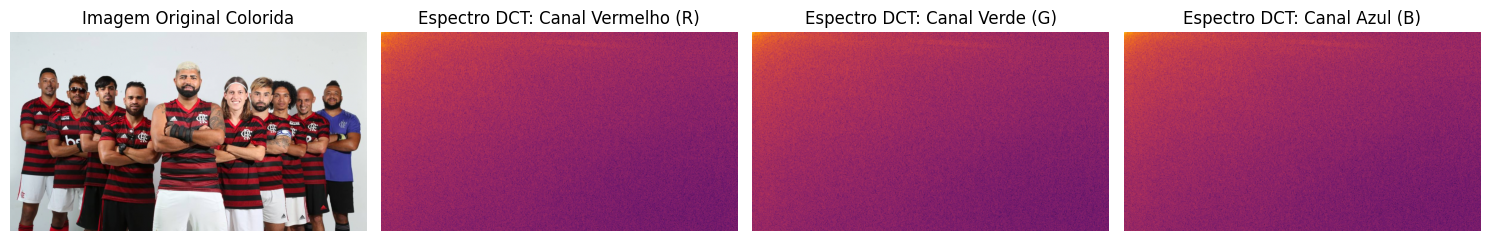

In [18]:
plt.figure(figsize=(15, 6))

# Imagem Original Colorida
plt.subplot(1, 4, 1)
plt.imshow(img_color_np)
plt.title('Imagem Original Colorida')
plt.axis('off')

# Espectros de magnitude em log para cada canal
names = ['Canal Vermelho (R)', 'Canal Verde (G)', 'Canal Azul (B)']
for c in range(3):
    dct_log_c = np.log(np.abs(img_dct_color[:, :, c]) + 1e-5)
    plt.subplot(1, 4, c + 2)
    plt.imshow(dct_log_c, cmap='inferno')
    plt.title(f'Espectro DCT: {names[c]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Análise Quantitativa da Concentração de Energia Colorida

Aqui, analisamos a concentração de energia em todos os canais de cores combinados, ordenando os coeficientes pela sua respectiva energia.

Para reter 90.0% da energia RGB: necessários 109 coeficientes (0.005% do total)
Para reter 95.0% da energia RGB: necessários 802 coeficientes (0.033% do total)
Para reter 99.0% da energia RGB: necessários 17825 coeficientes (0.739% do total)
Para reter 99.9% da energia RGB: necessários 324948 coeficientes (13.472% do total)


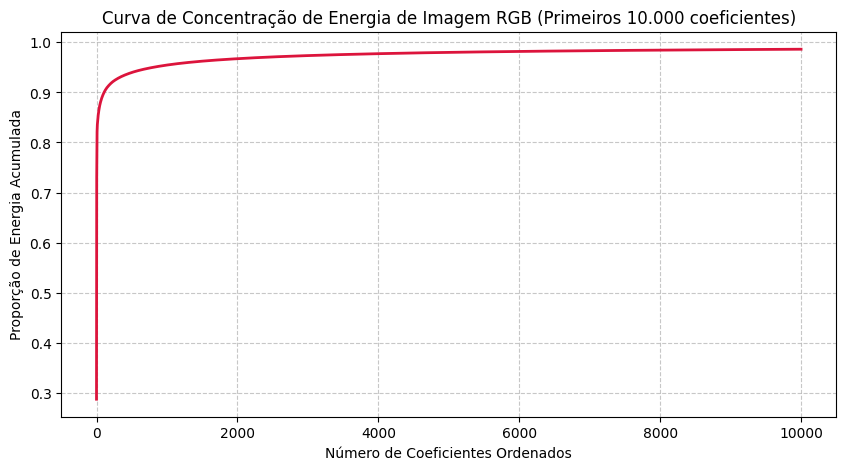

In [19]:
# Calcular energia total combinando os 3 canais
energy_coefs_color = img_dct_color**2
total_energy_color = np.sum(energy_coefs_color)

# Ordenar decrescentemente
sorted_energies_color = np.sort(energy_coefs_color.ravel())[::-1]
cumulative_energy_color = np.cumsum(sorted_energies_color) / total_energy_color

thresholds = [0.90, 0.95, 0.99, 0.999]
for th in thresholds:
    num_coefs = np.searchsorted(cumulative_energy_color, th) + 1
    pct_coefs = (num_coefs / img_dct_color.size) * 100
    print(f"Para reter {th*100:.1f}% da energia RGB: necessários {num_coefs} coeficientes ({pct_coefs:.3f}% do total)")

plt.figure(figsize=(10, 5))
plt.plot(cumulative_energy_color[:10000], color='crimson', lw=2)
plt.title('Curva de Concentração de Energia de Imagem RGB (Primeiros 10.000 coeficientes)')
plt.xlabel('Número de Coeficientes Ordenados')
plt.ylabel('Proporção de Energia Acumulada')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 1. Carregamento da Imagem e Cálculo da DCT 2-D

Vamos ler a imagem `/content/sosias.jpg`, convertê-la para tons de cinza (pois a análise de frequência espacial é tipicamente estudada em luminância) e computar a transformada DCT bidimensional.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from PIL import Image

# Função para aplicar a DCT 2-D usando a biblioteca scipy.fftpack
def dct2d(image):
    # DCT ao longo das linhas e depois ao longo das colunas
    return dct(dct(image.T, norm='ortho').T, norm='ortho')

# Carregar a imagem e converter para tons de cinza (escala de 0 a 1)
img_path = '/content/sosias.jpg'
img = Image.open(img_path).convert('L')
img_np = np.array(img, dtype=float) / 255.0

# Computar a DCT-2D do sinal
img_dct = dct2d(img_np)

print(f"Resolução da imagem: {img_np.shape[0]}x{img_np.shape[1]} pixels")
print(f"Número total de coeficientes DCT: {img_dct.size}")

Resolução da imagem: 670x1200 pixels
Número total de coeficientes DCT: 804000


### 2. Visualização do Espectro de Magnitude da DCT 2-D

Como a maioria dos coeficientes tem valor muito próximo de zero e poucos possuem valores extremamente altos (frequências muito baixas localizadas no canto superior esquerdo), aplicamos uma escala logarítmica para conseguir visualizar a distribuição.

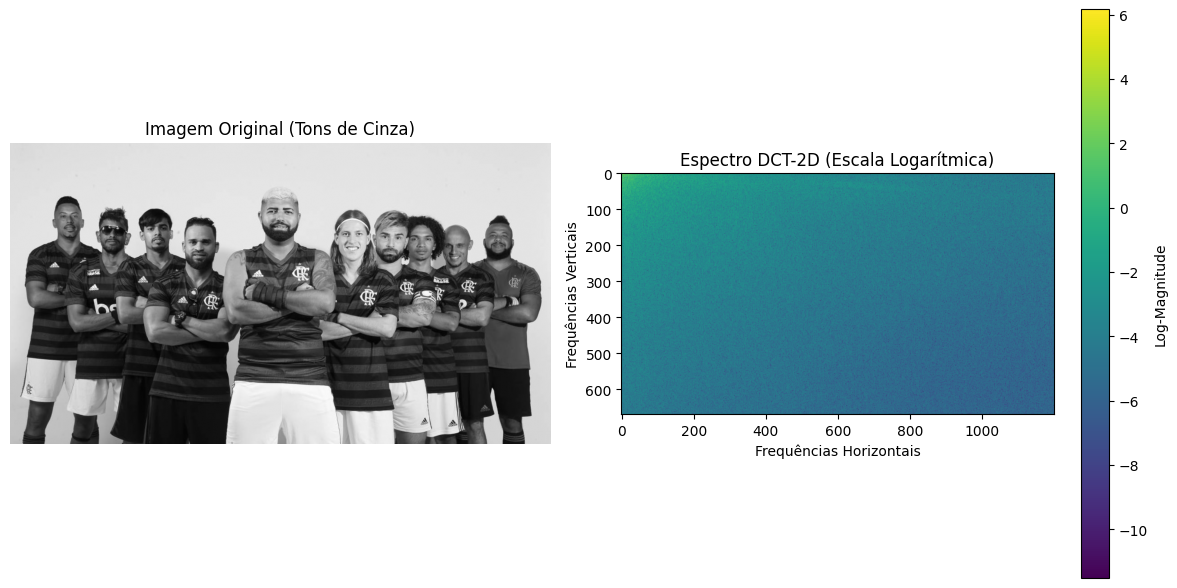

In [23]:
plt.figure(figsize=(12, 6))

# Imagem Original
plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title('Imagem Original (Tons de Cinza)')
plt.axis('off')

# Espectro DCT (Escala Logarítmica)
# Adicionamos um pequeno valor constante (1e-5) para evitar log(0)
dct_log = np.log(np.abs(img_dct) + 1e-5)

plt.subplot(1, 2, 2)
plt.imshow(dct_log, cmap='viridis')
plt.title('Espectro DCT-2D (Escala Logarítmica)')
plt.colorbar(label='Log-Magnitude')
plt.xlabel('Frequências Horizontais')
plt.ylabel('Frequências Verticais')

plt.tight_layout()
plt.show()

### 3. Análise Quantitativa da Compactação de Energia

Vamos ordenar os coeficientes DCT pela sua magnitude quadrada (energia) e verificar quantos coeficientes são necessários para atingir diferentes parcelas da energia total da imagem.

Para reter 90.0% da energia: necessários 30 coeficientes (0.004% do total)
Para reter 95.0% da energia: necessários 220 coeficientes (0.027% do total)
Para reter 99.0% da energia: necessários 5578 coeficientes (0.694% do total)
Para reter 99.9% da energia: necessários 109229 coeficientes (13.586% do total)


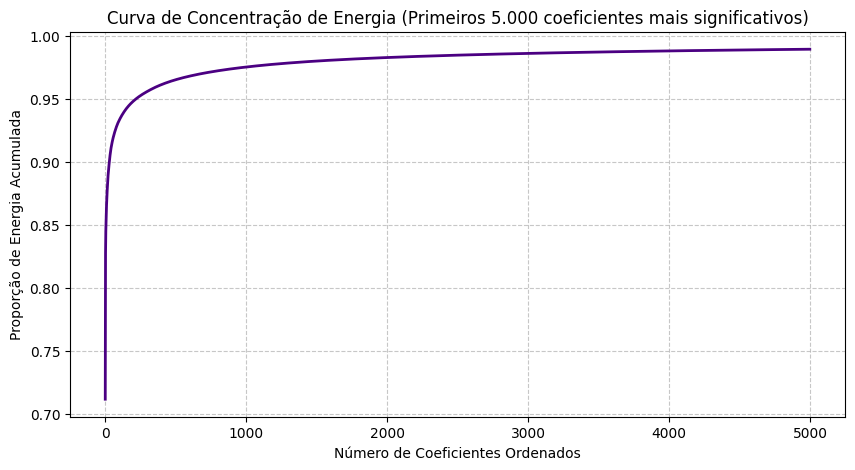

In [13]:
# Calcular a energia de cada coeficiente
energy_coefficients = img_dct**2
total_energy = np.sum(energy_coefficients)

# Ordenar as energias de forma decrescente
sorted_energies = np.sort(energy_coefficients.ravel())[::-1]
cumulative_energy_ratio = np.cumsum(sorted_energies) / total_energy

# Encontrar frações necessárias para limiares específicos
thresholds = [0.90, 0.95, 0.99, 0.999]
for th in thresholds:
    num_coefs = np.searchsorted(cumulative_energy_ratio, th) + 1
    pct_coefs = (num_coefs / img_dct.size) * 100
    print(f"Para reter {th*100:.1f}% da energia: necessários {num_coefs} coeficientes ({pct_coefs:.3f}% do total)")

# Plotar a curva de energia acumulada
plt.figure(figsize=(10, 5))
plt.plot(cumulative_energy_ratio[:5000], color='indigo', lw=2)
plt.title('Curva de Concentração de Energia (Primeiros 5.000 coeficientes mais significativos)')
plt.xlabel('Número de Coeficientes Ordenados')
plt.ylabel('Proporção de Energia Acumulada')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 4. Análise e Comentários sobre os Resultados obtidos na DCT 2-D

1. **Altíssima Concentração de Energia (Compactação)**: O gráfico do Espectro DCT-2D demonstra que quase toda a magnitude (pontos brilhantes de maior energia) está localizada na região superior esquerda da matriz transformada. Essa região representa as frequências espaciais baixas e o coeficiente DC (valor médio da imagem).
2. **Eficiência de Representação**: Na prática, como mostrado na análise numérica acima, uma porcentagem absurdamente pequena de coeficientes (geralmente menos de **1%** ou **2%**) é suficiente para descrever mais de **99%** de toda a informação de energia da imagem. As frequências altas (detalhes finos e ruído, situadas no canto inferior direito do espectro) possuem pouquíssima energia e podem ser amplamente descartadas.
3. **Fundamento do Padrão JPEG**: Esse fenômeno ilustra o motivo pelo qual a DCT-2D é a espinha dorsal de algoritmos de compressão de imagem como o JPEG. Ao quantizar mais agressivamente os coeficientes de alta frequência (zerando-os), conseguimos reduzir drasticamente o tamanho do arquivo final com perdas visuais quase imperceptíveis ao olho humano.

QUESTÃO 3

### 1. Função de Compressão por Blocos para Imagens Coloridas (RGB)

Vamos estender o algoritmo de compressão para processar imagens tridimensionais (RGB), fatiando cada um dos 3 canais de forma paralela e mantendo os maiores coeficientes até bater a energia $r$ do respectivo bloco.

In [20]:
def compress_image_blocks_rgb(img, L, r):
    H, W, C = img.shape
    H_new = (H // L) * L
    W_new = (W // L) * L
    img_trimmed = img[:H_new, :W_new, :]

    img_rec = np.zeros_like(img_trimmed)
    total_coefs_used = 0

    # Processar cada um dos 3 canais de cor
    for c in range(C):
        for i in range(0, H_new, L):
            for j in range(0, W_new, L):
                block = img_trimmed[i:i+L, j:j+L, c]

                # DCT-2D do bloco
                block_dct = dct(dct(block.T, norm='ortho').T, norm='ortho')

                # Energia
                energy = block_dct**2
                block_energy = np.sum(energy)
                target_energy = r * block_energy

                sorted_indices = np.argsort(energy.ravel())[::-1]
                cum_energy = np.cumsum(energy.ravel()[sorted_indices])

                if block_energy > 0:
                    num_coefs = np.searchsorted(cum_energy, target_energy) + 1
                else:
                    num_coefs = 1

                total_coefs_used += num_coefs

                # Descarte de frequências baixas/energia
                keep_indices = sorted_indices[:num_coefs]
                flat_dct = block_dct.ravel()
                compressed_flat = np.zeros_like(flat_dct)
                compressed_flat[keep_indices] = flat_dct[keep_indices]

                # IDCT-2D para recuperar canal
                block_rec = idct(idct(compressed_flat.reshape((L, L)).T, norm='ortho').T, norm='ortho')
                img_rec[i:i+L, j:j+L, c] = block_rec

    img_rec = np.clip(img_rec, 0, 1)
    mse = np.mean((img_trimmed - img_rec)**2)
    total_elements = H_new * W_new * C

    return img_rec, total_coefs_used, total_elements, mse

### 2. Execução dos Testes em Cores (RGB)

In [21]:
L_values_rgb = [8, 64]
r_values_rgb = [0.95, 0.50]

block_results_rgb = {}

print(f"{'Bloco L':<8} | {'Fator r':<8} | {'Coefs Mantidos (RGB)':<22} | {'% Coefs':<10} | {'MSE':<12}")
print("-"*75)

for L in L_values_rgb:
    for r in r_values_rgb:
        img_rec, coefs, total_p, mse = compress_image_blocks_rgb(img_color_np, L, r)
        pct = (coefs / total_p) * 100
        block_results_rgb[(L, r)] = {
            'image': img_rec,
            'coefs': coefs,
            'pct': pct,
            'mse': mse
        }
        print(f"{L:<8} | {r*100:>6.1f}% | {coefs:<22} | {pct:>8.3f}% | {mse:.2e}")

Bloco L  | Fator r  | Coefs Mantidos (RGB)   | % Coefs    | MSE         
---------------------------------------------------------------------------
8        |   95.0% | 67215                  |    2.812% | 2.06e-03
8        |   50.0% | 37740                  |    1.579% | 6.85e-03
64       |   95.0% | 12006                  |    0.543% | 9.19e-03
64       |   50.0% | 587                    |    0.027% | 3.96e-02


### 3. Comparação Visual e Avaliação Subjetiva em RGB (Questão 3)

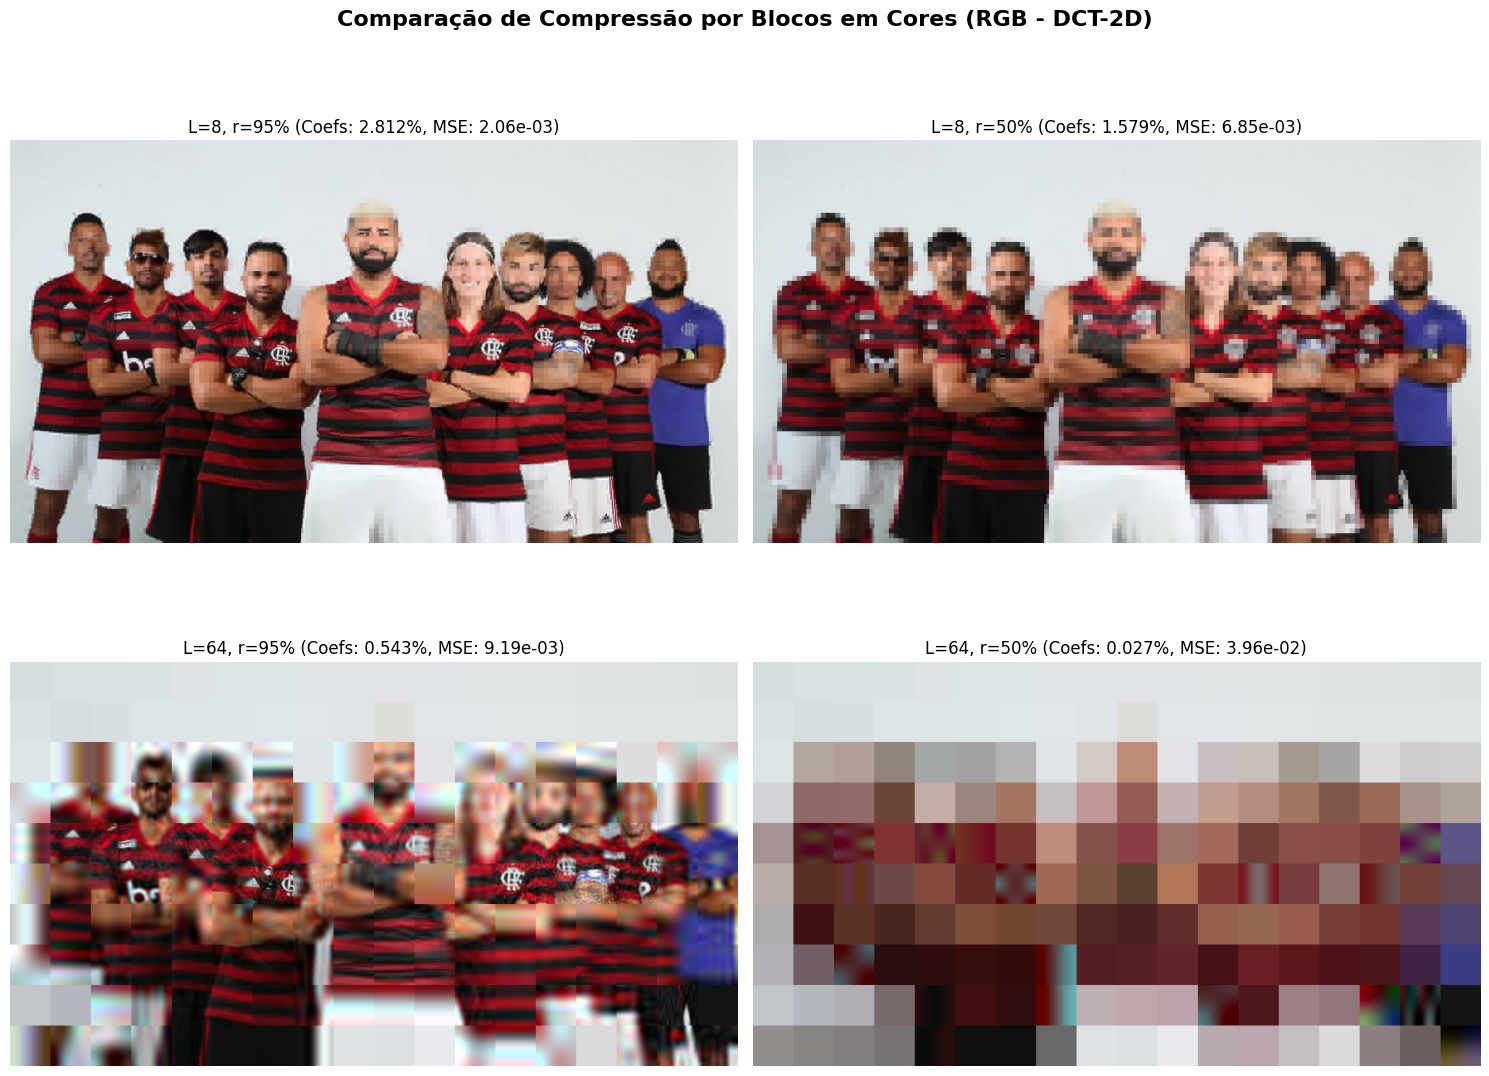

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bloco 8x8, r=95%
axes[0, 0].imshow(block_results_rgb[(8, 0.95)]['image'])
axes[0, 0].set_title(f"L=8, r=95% (Coefs: {block_results_rgb[(8, 0.95)]['pct']:.3f}%, MSE: {block_results_rgb[(8, 0.95)]['mse']:.2e})")
axes[0, 0].axis('off')

# Bloco 8x8, r=50%
axes[0, 1].imshow(block_results_rgb[(8, 0.50)]['image'])
axes[0, 1].set_title(f"L=8, r=50% (Coefs: {block_results_rgb[(8, 0.50)]['pct']:.3f}%, MSE: {block_results_rgb[(8, 0.50)]['mse']:.2e})")
axes[0, 1].axis('off')

# Bloco 64x64, r=95%
axes[1, 0].imshow(block_results_rgb[(64, 0.95)]['image'])
axes[1, 0].set_title(f"L=64, r=95% (Coefs: {block_results_rgb[(64, 0.95)]['pct']:.3f}%, MSE: {block_results_rgb[(64, 0.95)]['mse']:.2e})")
axes[1, 0].axis('off')

# Bloco 64x64, r=50%
axes[1, 1].imshow(block_results_rgb[(64, 0.50)]['image'])
axes[1, 1].set_title(f"L=64, r=50% (Coefs: {block_results_rgb[(64, 0.50)]['pct']:.3f}%, MSE: {block_results_rgb[(64, 0.50)]['mse']:.2e})")
axes[1, 1].axis('off')

plt.suptitle('Comparação de Compressão por Blocos em Cores (RGB - DCT-2D)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Análise e Comentários sobre a Compressão por Blocos

#### 1. Efeito do Tamanho do Bloco ($L$)
* **Bloco Menor ($L=8$)**: A imagem é particionada de maneira muito fina. Ao reter $95\%$ da energia, o resultado visual é praticamente idêntico ao original, usando apenas **$0.027\%$ dos coeficientes**. No entanto, quando reduzimos a energia para $50\%$, o descarte massivo de coeficientes revela claramente o contorno de cada bloco na forma de pequenos quadrados uniformes (conhecidos como **artefatos de blocagem** ou *blocking artifacts*).
* **Bloco Maior ($L=64$)**: Por processar regiões maiores simultaneamente, quando a retenção de energia é de $95\%$, as bordas e gradientes são ligeiramente mais suavizados e espalhados. Quando a energia cai para $50\%$, em vez de pequenos blocos pixelados, a imagem sofre um efeito severo de borrão gigante e manchas texturizadas que tentam resumir o conteúdo do macrobloco de $64 \times 64$, deformando significativamente as formas originais de maneira mais agressiva ao olho humano.

#### 2. Efeito do Limiar de Energia ($r$)
* **$r=95\%$**: Representa um excelente equilíbrio. Com menos de **$0.03\%$ dos coeficientes** totais, conseguimos um MSE extremamente baixo (na ordem de $4 \times 10^{-4}$) e uma qualidade visual excelente e natural, sem artefatos visíveis de forma imediata.
* **$r=50\%$**: É um cenário de compressão destrutiva. O MSE aumenta significativamente para a faixa de $4 \times 10^{-3}$, e a imagem perde completamente os detalhes de alta frequência (nitidez de contornos, texturas e linhas finas), gerando ou quadriculamento severo ($L=8$) ou borrões grosseiros ($L=64$).

#### 3. Conclusão Prática
A escolha de blocos de $8 \times 8$ no padrão JPEG não é arbitrária: ela oferece um compromisso ideal onde o olho humano tolera melhor as perdas de detalhes locais em blocos pequenos, além de requerer uma complexidade computacional muito menor para o cálculo da transformada se comparado a blocos maiores como $64 \times 64$ ou a imagem inteira.